# What should players of different abilities actually aim at?

The 3-dart MDP in `darts/mdp_3turn.py` tracks which dart of a visit is being thrown,
so it knows that a bust on dart 1 forfeits the rest of the visit. Solving it gives, for
every state `(score, dart, round start)`, both the expected number of darts to finish and
the aiming point that achieves it.

This notebook does for the full game what
[*Maximising the score of a single dart*](https://mjc239.github.io/darts/) did for one
throw: sweep the throwing accuracy $\sigma$ across the range of human ability and look at
how the recommended strategy changes.

A player is modelled, as before, by a spherically symmetric Gaussian throw
$Z \sim N(p, \sigma^2 I)$ around the aiming point $p$. Everything below is exact given
that model and the discretised board -- no simulation, no heuristics.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts.transitions import transition_arrays
from darts.mdp_3turn import ThreeDartMDP
from darts.utils import region_label

# Ordered quantity (player accuracy) -> single-hue sequential ramp, dark = accurate.
SIGMAS = [5.0, 7.5, 10.0, 15.0, 20.0, 30.0]
RAMP = plt.get_cmap('Blues')
SIG_COLOR = {s: RAMP(0.30 + 0.65 * (1 - i / (len(SIGMAS) - 1)))
             for i, s in enumerate(SIGMAS)}

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

BOARD_PIXELS = 512   # 0.88 mm per pixel
POINT_STRIDE = 2     # aiming points every 1.76 mm
GAME_START = 501

## Board resolution

Everything here depends on a discretisation of the board, so it is worth checking that the
answers have converged. The treble bed is 8 mm wide and the double bed is 8 mm wide, so a
128-pixel board (3.5 mm per pixel) puts barely two pixels across a scoring ring -- not
enough. The FFT construction in `darts.transitions` makes fine boards cheap, so we can
afford 512 pixels.

In [2]:
rows = []
for px in [128, 256, 512, 1024]:
    tr = transition_arrays(px, 10.0, point_stride=max(1, px // 256))
    es = tr['probs'] @ tr['allowed_scores']
    best = tr['points'][es.argmax()]
    m = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'], 170).solve()
    rows.append({'board pixels': px, 'mm/pixel': round(tr['mm_per_pixel'], 2),
                 'aiming points': len(tr['points']),
                 'best single-dart aim': region_label(best, px),
                 'E[score]': round(es.max(), 3),
                 'darts from 170': round(m.expected_darts(170), 4)})
pd.DataFrame(rows).set_index('board pixels')

,mm/pixel,aiming points,best single-dart aim,E[score],darts from 170
board pixels,,,,,
128,3.52,7441,T20,29.396,8.1256
256,1.76,29829,T20,29.089,8.3684
512,0.88,29829,T20,29.423,8.4441
1024,0.44,29969,T20,29.417,8.4356


The recommended single-dart aim is the treble 20 at every resolution, but the *value* is
not converged at 128 pixels: 8.13 expected darts from 170 against 8.44 at 512, a 3.7%
error, and it is still moving at 256. Since the whole point of the exercise is to compare
strategies whose values differ by hundredths of a dart, we use 512 pixels throughout.
(Before the coordinate-grid fix in `darts/dartboards.py` and `darts/stats.py`, the
128-pixel board also got the *aim* wrong.)

## Solving across the ability range

Each solve is a full 501 game: every score from 2 to 501, all three darts of the visit,
and every legal round-start score.

In [3]:
import time

models, boards = {}, {}
for sigma in SIGMAS:
    t0 = time.perf_counter()
    tr = transition_arrays(BOARD_PIXELS, sigma, point_stride=POINT_STRIDE)
    m = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'],
                     GAME_START).solve()
    models[sigma], boards[sigma] = m, tr
    print(f'sigma = {sigma:>4} mm | {len(tr["points"]):>6} aiming points | '
          f'{time.perf_counter() - t0:5.1f} s | {m.expected_darts():6.2f} darts')

sigma =  5.0 mm |  29377 aiming points |  47.7 s |  13.11 darts


sigma =  7.5 mm |  29589 aiming points |  47.7 s |  16.27 darts


sigma = 10.0 mm |  29829 aiming points |  25.7 s |  19.65 darts


sigma = 15.0 mm |  30269 aiming points |  14.0 s |  27.36 darts


sigma = 20.0 mm |  30661 aiming points |  14.8 s |  35.13 darts


sigma = 30.0 mm |  31593 aiming points |  37.3 s |  49.24 darts


In [4]:
summary = pd.DataFrame({
    'sigma (mm)': SIGMAS,
    'darts to finish 501': [models[s].expected_darts() for s in SIGMAS],
    '3-dart average': [3 * GAME_START / models[s].expected_darts() for s in SIGMAS],
    'darts from 170': [models[s].expected_darts(170) for s in SIGMAS],
    'darts from 40': [models[s].expected_darts(40) for s in SIGMAS],
}).set_index('sigma (mm)').round(2)
summary

,darts to finish 501,3-dart average,darts from 170,darts from 40
sigma (mm),,,,
5.0,13.11,114.63,5.16,1.76
7.5,16.27,92.37,6.85,2.55
10.0,19.65,76.49,8.44,3.41
15.0,27.36,54.93,12.15,5.61
20.0,35.13,42.79,16.51,8.61
30.0,49.24,30.52,26.66,17.05


The third column is the number a darts player would recognise. It anchors the model to
reality: the very best players in the world average a little over 100, a good county
player is around 80-90, a decent league player 60, and a casual pub player 30-45. So
$\sigma \approx 5$ mm is beyond human, $\sigma \approx 10$ mm is a strong club player,
and $\sigma \gtrsim 25$ mm is a beginner.

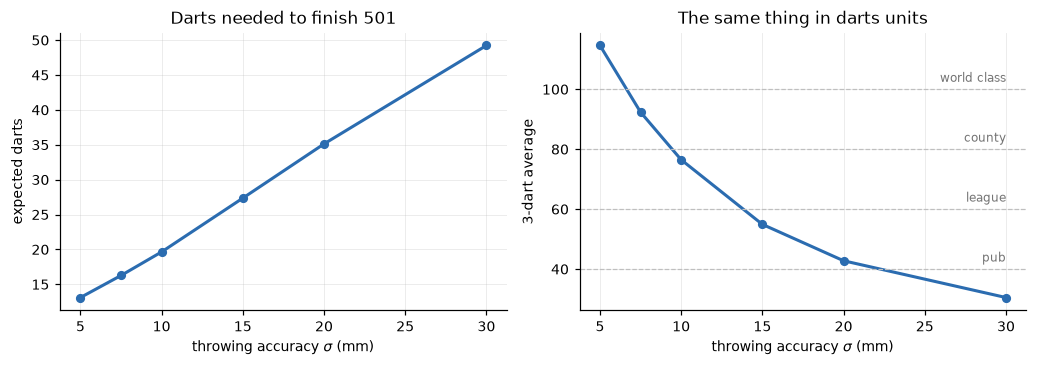

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
sig = np.array(SIGMAS)
axes[0].plot(sig, summary['darts to finish 501'], color='#2b6cb0', lw=2, marker='o', ms=5)
axes[0].set_xlabel(r'throwing accuracy $\sigma$ (mm)')
axes[0].set_ylabel('expected darts')
axes[0].set_title('Darts needed to finish 501')

axes[1].plot(sig, summary['3-dart average'], color='#2b6cb0', lw=2, marker='o', ms=5)
for level, name in [(100, 'world class'), (80, 'county'), (60, 'league'), (40, 'pub')]:
    axes[1].axhline(level, color='0.75', lw=0.8, ls='--')
    axes[1].text(sig.max(), level + 1.5, name, ha='right', va='bottom',
                 fontsize=8, color='0.45')
axes[1].set_xlabel(r'throwing accuracy $\sigma$ (mm)')
axes[1].set_ylabel('3-dart average')
axes[1].set_title('The same thing in darts units')
fig.tight_layout()

## Where to aim the first dart of a scoring visit

For a big score there is nothing to set up yet, so the first dart is a pure scoring dart.
The heat maps below show the *value of aiming at each point* -- the expected number of
darts still needed after aiming there and then playing optimally -- with the optimum
marked.

In [ ]:
def q_map(model, board, score, dart, round_start=None):
    """Scatter Q-values back onto the board grid for plotting."""
    q = model.q_values(score, dart, round_start)
    grid = np.full(board['board'].shape, np.nan)
    pts = board['points']
    grid[pts[:, 0], pts[:, 1]] = -q     # positive = expected darts remaining
    return grid, q

def show_boards(states, sigmas, suptitle):
    fig, axes = plt.subplots(len(states), len(sigmas),
                             figsize=(1.9 * len(sigmas), 2.15 * len(states)),
                             squeeze=False)
    for r, (score, dart, rs) in enumerate(states):
        for c, sigma in enumerate(sigmas):
            ax = axes[r][c]
            m, tr = models[sigma], boards[sigma]
            grid, q = q_map(m, tr, score, dart, rs)
            # Most aiming points are poor; clip hard so the good ones keep
            # the colour resolution.
            lo, hi = np.nanpercentile(grid, [0, 15])
            # generate_dartboard puts increasing y at increasing row index, so
            # origin='lower' shows the board the way a player sees it.
            ax.imshow(grid, cmap='cividis_r', vmin=lo, vmax=hi, origin='lower')
            best = tr['points'][m.policy(score, dart, rs if rs else score)]
            ax.plot(best[1], best[0], marker='+', ms=11, mew=1.8, color='#e63946')
            ax.set_axis_off()
            if r == 0:
                ax.set_title(f'$\\sigma$ = {sigma:g} mm', fontsize=9)
            if c == 0:
                ax.text(-0.08, 0.5, f'{score}, dart {dart}', fontsize=9, rotation=90,
                        ha='right', va='center', transform=ax.transAxes)
            ax.text(0.5, -0.02, region_label(best, BOARD_PIXELS), fontsize=8.5,
                    ha='center', va='top', transform=ax.transAxes, color='#e63946')
    fig.suptitle(suptitle, y=1.02, fontsize=11)
    fig.tight_layout()
    return fig

_ = show_boards([(501, 1, None)], SIGMAS,
                'Value of each aiming point: first dart on 501 (brighter = fewer darts needed)')

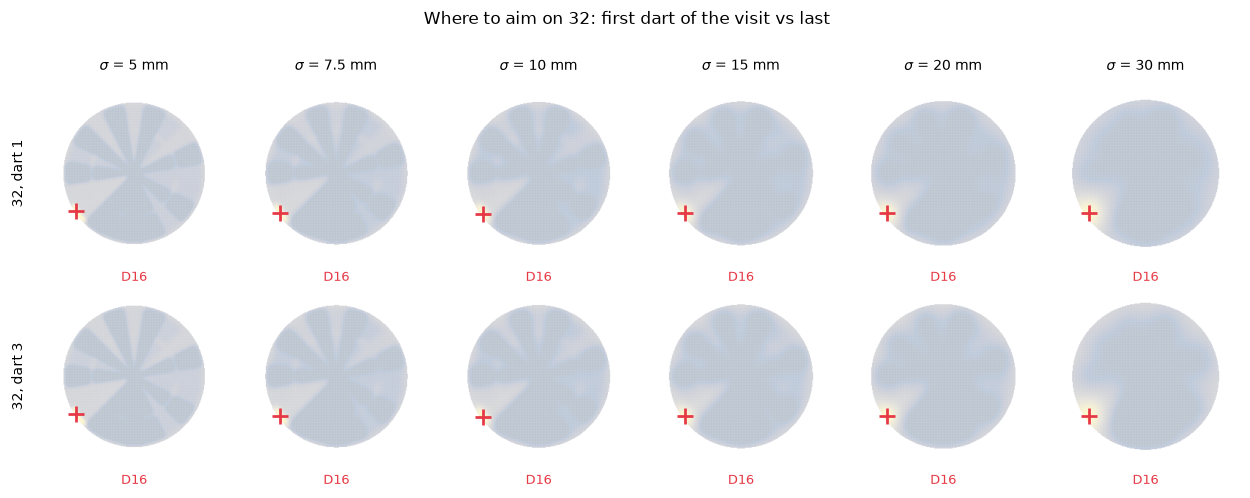

In [7]:
_ = show_boards([(32, 1, 32), (32, 3, 32)], SIGMAS,
                'Where to aim on 32: first dart of the visit vs last')

The optimum tracks the familiar single-dart story -- treble 20 for the accurate, sliding
to the treble 19 and then to the fat single 19/16 region as $\sigma$ grows -- but that is
not the whole picture. What the heat map adds is *how much it matters*: for the accurate
player the bright spot is a small island, while for the beginner the whole middle of the
board is nearly flat.

In [8]:
rows = []
for sigma in SIGMAS:
    m, tr = models[sigma], boards[sigma]
    for score in [501, 301, 170, 141, 101]:
        idx, q = m.best_points(score, 1, n=400)
        best_lab = region_label(tr['points'][idx[0]], BOARD_PIXELS)
        # best alternative in a *different* board region
        alt = next(((i, v) for i, v in zip(idx, q)
                    if region_label(tr['points'][i], BOARD_PIXELS) != best_lab), None)
        rows.append({'sigma': sigma, 'score': score, 'aim': best_lab,
                     'darts': round(-q[0], 3),
                     'best alternative': region_label(tr['points'][alt[0]], BOARD_PIXELS),
                     'cost of alternative (darts)': round(q[0] - alt[1], 4)})
pd.DataFrame(rows).pivot(index='score', columns='sigma',
                         values=['aim', 'cost of alternative (darts)'])

aim                            cost of alternative (darts)          \
sigma  5.0   7.5   10.0 15.0 20.0 30.0                        5.0     7.5    
score                                                                        
101     T17   T19   T19  T19   19  T19                      0.1513  0.0055   
141    BULL  BULL  BULL  T19   19  T19                      0.0699  0.0403   
170     T20   T20   T20  T20   19  T19                      0.1535  0.0072   
301     T20   T20   T20  T20   19  T19                      0.0481   0.029   
501     T20   T20   T20  T20   19  T19                      0.0432  0.0556   

                                       
sigma    10.0    15.0    20.0    30.0  
score                                  
101    0.0281  0.0072  0.0003  0.0006  
141    0.0076  0.0001  0.0009  0.0009  
170     0.004  0.0017  0.0006   0.001  
301    0.0294  0.0027  0.0007   0.001  
501    0.0291  0.0027  0.0007   0.001

The cost column is the price of aiming at the best *other* region instead. It is tiny at
the top of the board -- a strong player who aims treble 19 all night instead of treble 20
gives up only a few hundredths of a dart per visit -- which is exactly why the argmax
flips around between neighbouring trebles as $\sigma$ changes. Those flips are real but
they are not worth much. Where the choice does matter is in the checkout zone.

## Checkouts: the same score, three different darts

This is what the round-aware model buys us that a memoryless one-dart MDP cannot express.
On the last dart of a visit there is no point setting anything up, and a bust costs
nothing that has not already been lost; on the first dart of a visit a bust throws away
two more darts. The optimal aim for the *same score* therefore depends on which dart it is.

In [9]:
def aim_table(sigma, scores, darts=(1, 2, 3)):
    m, tr = models[sigma], boards[sigma]
    out = {}
    for d in darts:
        out[f'dart {d}'] = [region_label(tr['points'][m.policy(s, d, s)], BOARD_PIXELS)
                            for s in scores]
    return pd.DataFrame(out, index=pd.Index(scores, name='score'))

checkout_scores = [60, 50, 40, 36, 32, 24, 20, 18, 16, 10, 8, 6, 5, 4, 3, 2]
pd.concat({f'sigma={s:g}': aim_table(s, checkout_scores) for s in [7.5, 15.0, 30.0]},
          axis=1)

sigma=7.5               sigma=15               sigma=30              
         dart 1 dart 2 dart 3   dart 1 dart 2 dart 3   dart 1 dart 2 dart 3
score                                                                      
60           20     20     20       20     20     20       20     20     20
50         BULL   BULL   BULL       18     18     18       25   BULL     14
40          D20    D20    D20      D20    D20    D20      D20    D20    D20
36          D18    D18    D18      D18    D18    D18      D18    D18    D18
32          D16    D16    D16      D16    D16    D16      D16    D16    D16
24          D12    D12    D12      D12    D12    D12      D12    D12   miss
20          D10    D10    D10      D10    D10    D10      D10    D10   miss
18           D9     D9     D9       D9     D9     D9       D9     D9   miss
16           D8     D8     D8       D8     D8     D8       D8     D8     D8
10           D5     D5     D5       D5     D5     D5       D5     D5   miss
8            D4     D4     D4       D4     D4     D4       D4     D4     D4
6            D3     D3     D3       D3     D3   miss       D3     D3      2
5             1      1      3        1      1      1        1      1      1
4            D2     D2     D2       D2     D2     D2       D2     D2     D2
3             1      1      1        1      1      1        1      1      1
2            D1     D1     D1       D1     D1     D1       D1     D1     D1

Read the `dart 1` and `dart 3` columns against each other. For a strong player they agree
almost everywhere: go straight at the double, from any dart. As $\sigma$ grows they come
apart, and they come apart in a specific direction -- on dart 3 the weak player stops
aiming at the double and starts aiming at a *safe* part of the board.

The reason is that on the last dart of a visit the only thing that matters is the score
left behind. Missing a double inwards leaves an odd number, and odd numbers are expensive
for a bad player because they need another dart just to get back to an even number. So the
last dart is thrown to protect the number rather than to win. Here is that trade-off
priced out.

In [10]:
def outcome_profile(sigma, score, dart, point_idx):
    m, tr = models[sigma], boards[sigma]
    P, CP, S = tr['probs'], tr['checkout_probs'], tr['allowed_scores']
    p, cp = P[point_idx], CP[point_idx]
    checkout = cp[S == score].sum() if (S == score).any() else 0.0
    valid = S <= score - 2
    left = score - S[valid]
    return {
        'aim': region_label(tr['points'][point_idx], BOARD_PIXELS),
        'P(checkout)': checkout,
        'P(leaves even)': p[valid][left % 2 == 0].sum(),
        'P(leaves odd)': p[valid][left % 2 == 1].sum(),
        'P(no change / bust)': 1 - checkout - p[valid].sum(),
        'darts after': -m.q_values(score, dart, score)[point_idx],
    }

rows = []
for sigma in [7.5, 20.0, 30.0]:
    m, tr = models[sigma], boards[sigma]
    for score in [32, 20]:
        chosen = m.policy(score, 3, score)
        # a player who always goes at the double: the aim that maximises the
        # chance of hitting it
        target = f'D{score // 2}'
        naive = int(tr['checkout_probs'][:, tr['allowed_scores'] == score].ravel().argmax())
        for idx, tag in [(chosen, 'MDP'), (naive, f'max P({target})')]:
            rows.append({'sigma': sigma, 'score': score, 'policy': tag,
                         **outcome_profile(sigma, score, 3, idx)})
pd.DataFrame(rows).set_index(['sigma', 'score', 'policy']).round(3)

aim  P(checkout)  P(leaves even)  P(leaves odd)  \
sigma score policy                                                         
7.5   32    MDP          D16        0.405           0.595          0.000   
            max P(D16)   D16        0.405           0.595          0.000   
      20    MDP          D10        0.404           0.596          0.000   
            max P(D10)   D10        0.406           0.594          0.000   
20.0  32    MDP          D16        0.126           0.836          0.037   
            max P(D16)   D16        0.127           0.826          0.046   
      20    MDP          D10        0.127           0.829          0.032   
            max P(D10)   D10        0.128           0.808          0.047   
30.0  32    MDP          D16        0.064           0.853          0.078   
            max P(D16)   D16        0.065           0.835          0.094   
      20    MDP         miss        0.064           0.856          0.060   
            max P(D10)   D10        0.065           0.817          0.090   

                        P(no change / bust)  darts after  
sigma score policy                                        
7.5   32    MDP                       0.000        2.470  
            max P(D16)                0.000        2.470  
      20    MDP                       0.000        2.630  
            max P(D10)                0.000        2.632  
20.0  32    MDP                       0.001        8.130  
            max P(D16)                0.001        8.137  
      20    MDP                       0.012        8.669  
            max P(D10)                0.016        8.690  
30.0  32    MDP                       0.005       16.350  
            max P(D16)                0.006       16.365  
      20    MDP                       0.020       17.001  
            max P(D10)                0.028       17.053

## When does a visit finish?

A more player-facing summary: given a score at the start of a visit, what is the chance of
checking out with those three darts?

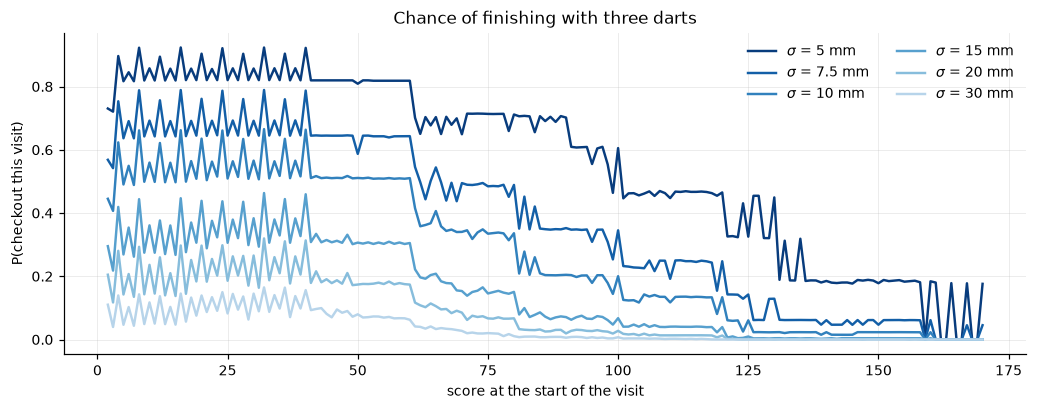

In [11]:
def checkout_chance(model, board, score):
    '''Exact probability of finishing within the current visit under the solved
    policy, by propagating the score distribution through the three darts.'''
    P, CP, S = board['probs'], board['checkout_probs'], board['allowed_scores']
    dist, win = {score: 1.0}, 0.0
    for dart in (1, 2, 3):
        nxt = {}
        for u, w in dist.items():
            i = model.policy(u, dart, score)
            p, cp = P[i], CP[i]
            hit = S == u
            if hit.any():
                win += w * cp[hit].sum()        # checked out
            valid = S <= u - 2
            for sj, pj in zip(S[valid], p[valid]):
                if pj > 1e-12:                   # anything else ends the visit
                    nxt[u - sj] = nxt.get(u - sj, 0.0) + w * pj
        dist = nxt
    return win

scores = list(range(2, 171))
fig, ax = plt.subplots(figsize=(9.5, 3.8))
for sigma in SIGMAS:
    y = [checkout_chance(models[sigma], boards[sigma], s) for s in scores]
    ax.plot(scores, y, color=SIG_COLOR[sigma], lw=1.6, label=f'$\\sigma$ = {sigma:g} mm')
ax.set_xlabel('score at the start of the visit')
ax.set_ylabel('P(checkout this visit)')
ax.set_title('Chance of finishing with three darts')
ax.legend(loc='upper right', ncols=2)
fig.tight_layout()

The sawtooth is the odd/even structure: an odd score always needs a dart spent making it
even, so it is worth several percentage points of checkout chance. The teeth are deep for
weak players and shallow for strong ones, and the whole curve falls off a cliff above 100
or so for anyone but the best.

## Bogey numbers

Which scores are worse than they look? Plotting expected darts against the score left
shows the awkward numbers as local bumps.

,sigma=5,sigma=7.5,sigma=10,sigma=15,sigma=20,sigma=30
#1,102,3,3,3,3,3
#2,6,6,6,6,6,6
#3,99,22,22,34,10,10
#4,3,30,30,26,14,29
#5,22,26,34,30,34,7
#6,30,34,26,22,18,120
#7,26,119,14,14,30,119
#8,34,14,10,10,26,34


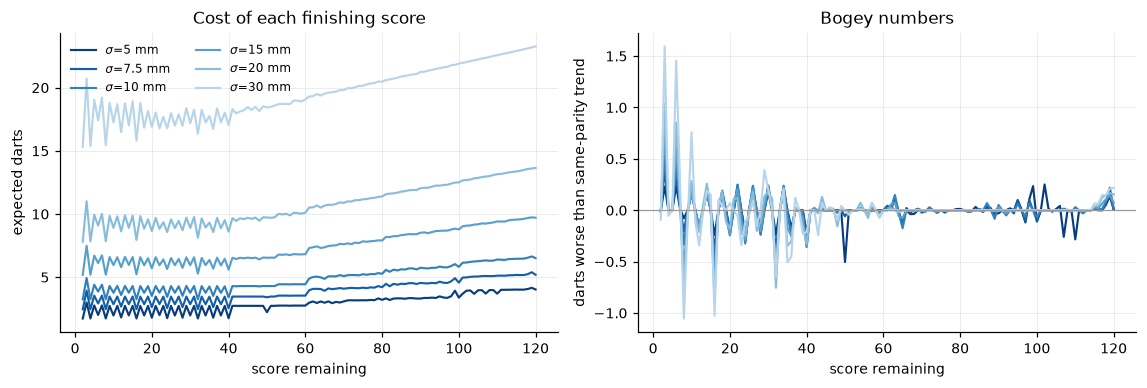

In [12]:
def bogey_excess(v, scores):
    """How much worse a score is than its same-parity neighbours. Comparing
    across parities is meaningless: an odd score always costs an extra dart."""
    out = np.full(len(v), np.nan)
    for parity in (0, 1):
        m = scores % 2 == parity
        s = pd.Series(v[m])
        out[m] = v[m] - s.rolling(7, center=True, min_periods=1).median().values
    return out

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
xs = np.arange(2, 121)
for sigma in SIGMAS:
    v = models[sigma].expected_darts(xs)
    axes[0].plot(xs, v, color=SIG_COLOR[sigma], lw=1.4, label=f'$\\sigma$={sigma:g} mm')
    axes[1].plot(xs, bogey_excess(v, xs), color=SIG_COLOR[sigma], lw=1.4)
axes[0].set_xlabel('score remaining'); axes[0].set_ylabel('expected darts')
axes[0].set_title('Cost of each finishing score')
axes[0].legend(ncols=2, fontsize=8)
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].set_xlabel('score remaining')
axes[1].set_ylabel('darts worse than same-parity trend')
axes[1].set_title('Bogey numbers')
fig.tight_layout()

worst = {}
for sigma in SIGMAS:
    v = models[sigma].expected_darts(xs)
    worst[f'sigma={sigma:g}'] = list(xs[np.argsort(-bogey_excess(v, xs))[:8]])
pd.DataFrame(worst, index=[f'#{i+1}' for i in range(8)])

## How much does the round structure actually matter?

The published single-player MDP is memoryless: a bust simply returns you to the same score
and costs one dart. The 3-dart model knows that a bust on the first dart of a visit costs
the other two darts as well. Comparing the two isolates the value of modelling the visit.

In [13]:
rows = []
for sigma in SIGMAS:
    m, tr = models[sigma], boards[sigma]
    turns = ThreeDartMDP(tr['probs'], tr['checkout_probs'], tr['allowed_scores'], GAME_START,
               dart_cost=0.0, turn_cost=1.0).solve()
    same = sum(m.pol1[s] == turns.pol1[s] for s in range(2, GAME_START + 1))
    rows.append({'sigma (mm)': sigma,
                 'darts (min-darts policy)': m.expected_darts(),
                 'visits (min-darts policy)': None,
                 'visits (min-visits policy)': turns.expected_darts(),
                 'first-dart aims that differ': GAME_START - 1 - same})
    d, r = m.simulate(4000, seed=3)
    rows[-1]['visits (min-darts policy)'] = r.mean()
pd.DataFrame(rows).set_index('sigma (mm)').round(3)

,darts (min-darts policy),visits (min-darts policy),visits (min-visits policy),first-dart aims that differ
sigma (mm),,,,
5.0,13.112,4.700,4.666,87
7.5,16.271,5.791,5.754,64
10.0,19.649,6.960,6.904,74
15.0,27.362,9.763,9.602,76
20.0,35.128,12.624,12.472,99
30.0,49.244,18.851,18.199,108


The two objectives are close but not identical. Minimising *darts thrown* treats a bust on
the first dart as costing one dart, because the other two are never thrown; minimising
*visits* charges it a whole visit. The second is the quantity that matters in a race
against an opponent, and it is very slightly more conservative around the doubles. The
first-dart aims disagree at a few dozen scores -- all of them low.

## Summary

* Board discretisation matters more than one might expect: at 128 pixels the model gets
  the single-dart answer wrong. 512 pixels is enough.
* For scoring, the MDP essentially reproduces the myopic "maximise expected score" answer,
  and the choice between neighbouring trebles is worth very little.
* For checkouts, the round structure matters a lot, and it matters *more* the worse the
  player is. Strong players should go straight at the double on every dart. Weak players
  should protect the number with their last dart of a visit rather than chase the double.
* Odd numbers are the main structural cost in the endgame, and the penalty grows sharply
  with $\sigma$.